# Renewable Energy Forecasting — Phase 3: Modelling
### Shell Internship Project

In this notebook we will:
1. Split data into train and test sets
2. Build a **SARIMA** model for solar and wind
3. Build a **Prophet** model for solar and wind
4. Compare both models using RMSE and MAE
5. Plot forecasts vs actuals
6. Save results for the Streamlit dashboard

## 0. Imports & Load Data

In [3]:
!pip install prophet statsmodels scikit-learn --quiet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

# Load daily dataset from Phase 2
df = pd.read_csv('data/daily_energy_weather_london.csv', index_col='time', parse_dates=True)

print('Shape:', df.shape)
print('Date range:', df.index.min(), '->', df.index.max())
df[['solar_cf', 'wind_cf']].head()

Shape: (1826, 17)
Date range: 2019-01-01 00:00:00 -> 2023-12-31 00:00:00


,solar_cf,wind_cf
time,,
2019-01-01,0.022583,0.323208
2019-01-02,0.067750,0.189208
2019-01-03,0.051000,0.070625
2019-01-04,0.053042,0.116333
2019-01-05,0.025625,0.201000


## 1. Train / Test Split

We train on 2019–2022 and test on 2023 (the most recent full year).
This is called **out-of-sample evaluation** — we never let the model see 2023 during training.

Train: 2019-01-01 -> 2022-12-31  (1461 days)
Test : 2023-01-01  -> 2023-12-31  (365 days)


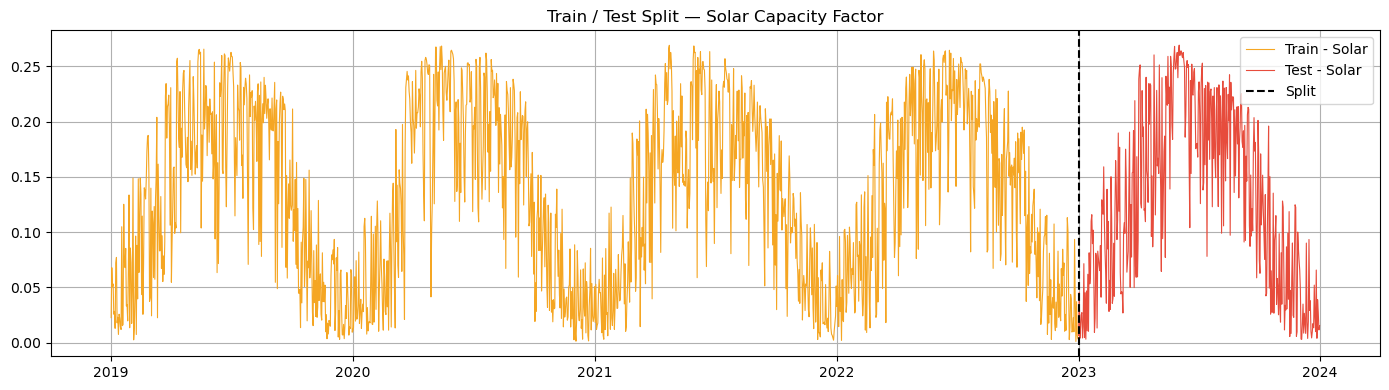

In [6]:
SPLIT_DATE = '2023-01-01'

train = df[df.index < SPLIT_DATE]
test  = df[df.index >= SPLIT_DATE]

print(f'Train: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} days)')
print(f'Test : {test.index.min().date()}  -> {test.index.max().date()}  ({len(test)} days)')

# Plot the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['solar_cf'], color='#f5a623', linewidth=0.8, label='Train - Solar')
ax.plot(test.index,  test['solar_cf'],  color='#e74c3c', linewidth=0.8, label='Test - Solar')
ax.axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle='--', linewidth=1.5, label='Split')
ax.set_title('Train / Test Split — Solar Capacity Factor')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Helper Functions

Define evaluation and plotting functions we will reuse for both models.

In [8]:
def evaluate(actual, predicted, model_name, target_name):
    """Print RMSE and MAE for a set of predictions."""
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    print(f'[{model_name} | {target_name}]  RMSE: {rmse:.4f}   MAE: {mae:.4f}')
    return {'model': model_name, 'target': target_name, 'rmse': rmse, 'mae': mae}


def plot_forecast(train, test, forecast, title, color):
    """Plot train history, actuals, and forecast together."""
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train.index[-90:], train.values[-90:], color='grey',
            linewidth=1, alpha=0.7, label='Train (last 90 days)')
    ax.plot(test.index, test.values,     color='black',
            linewidth=1.5, label='Actual')
    ax.plot(test.index, forecast,        color=color,
            linewidth=1.5, linestyle='--', label='Forecast')
    ax.set_title(title)
    ax.set_ylabel('Capacity Factor')
    ax.legend()
    plt.tight_layout()
    return fig


# Store all results here for the final comparison
results = []

## 3. SARIMA — Solar

SARIMA(p,d,q)(P,D,Q,s) where s=365 for yearly seasonality.

Based on the ACF/PACF plots from Phase 2, we start with:
- (p=2, d=0, q=2) — short-term AR and MA terms
- (P=1, D=1, Q=1, s=365) — one seasonal cycle per year with differencing

In [10]:
print('Fitting SARIMA for solar... (this takes ~30 seconds)')
# s=7 captures weekly seasonality — fast and effective.
# Prophet will handle the longer yearly seasonal pattern in section 5.
sarima_solar = SARIMAX(
    train['solar_cf'],
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print('Done!')
print(sarima_solar.summary().tables[0])

Fitting SARIMA for solar... (this takes ~30 seconds)


C:\Users\talha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\talha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\talha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Done!
                                      SARIMAX Results                                      
Dep. Variable:                            solar_cf   No. Observations:                 1461
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 7)   Log Likelihood                2374.559
Date:                             Wed, 11 Mar 2026   AIC                          -4735.119
Time:                                     15:28:13   BIC                          -4698.193
Sample:                                 01-01-2019   HQIC                         -4721.336
                                      - 12-31-2022                                         
Covariance Type:                               opg                                         


[SARIMA | Solar]  RMSE: 0.0929   MAE: 0.0776


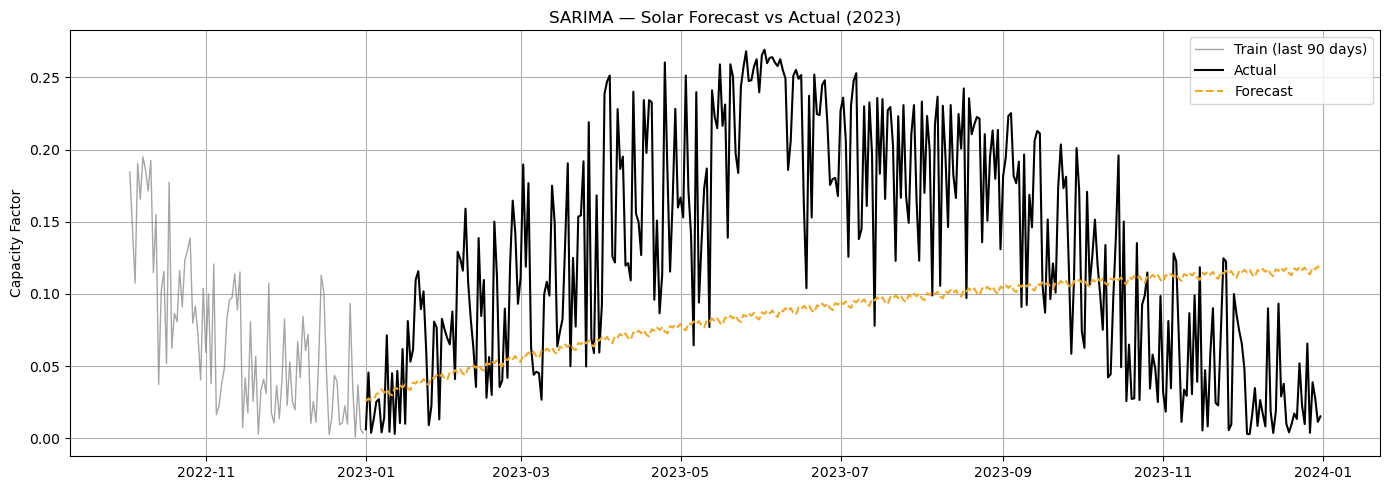

In [11]:
# Forecast on the test period
sarima_solar_pred = sarima_solar.forecast(steps=len(test))
sarima_solar_pred = np.clip(sarima_solar_pred, 0, 1)  # capacity factor must be 0-1

res = evaluate(test['solar_cf'], sarima_solar_pred, 'SARIMA', 'Solar')
results.append(res)

fig = plot_forecast(
    train['solar_cf'], test['solar_cf'],
    sarima_solar_pred,
    'SARIMA — Solar Forecast vs Actual (2023)',
    '#f5a623'
)
fig.savefig('data/sarima_solar_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SARIMA — Wind

In [13]:
print('Fitting SARIMA for wind... (this takes ~30 seconds)')
sarima_wind = SARIMAX(
    train['wind_cf'],
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print('Done!')

Fitting SARIMA for wind... (this takes ~30 seconds)


C:\Users\talha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\talha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\talha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Done!


[SARIMA | Wind]  RMSE: 0.1965   MAE: 0.1598


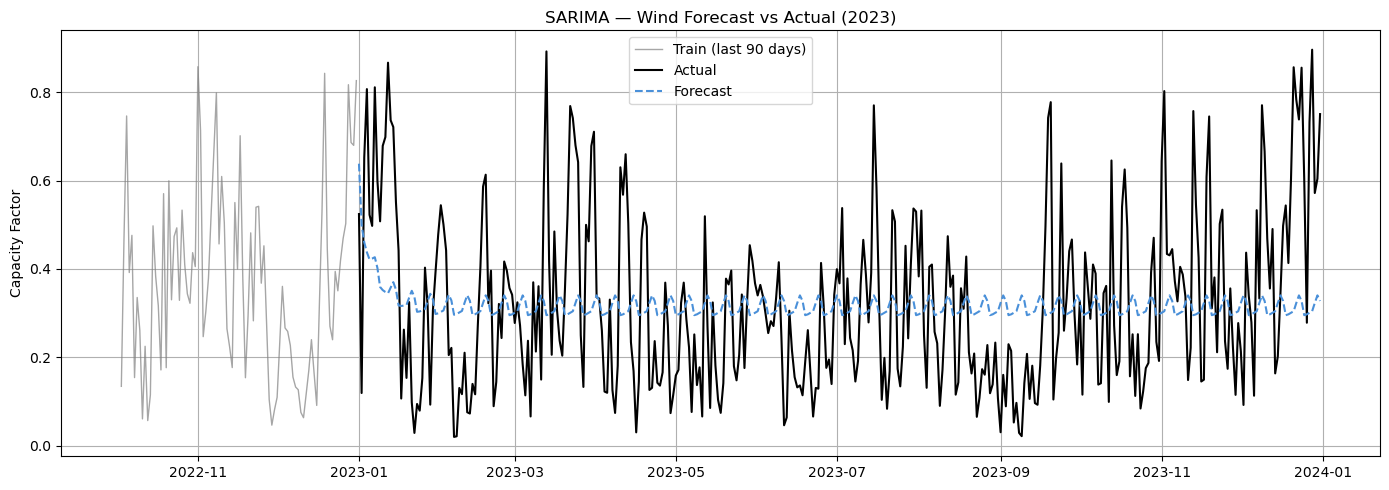

In [14]:
sarima_wind_pred = sarima_wind.forecast(steps=len(test))
sarima_wind_pred = np.clip(sarima_wind_pred, 0, 1)

res = evaluate(test['wind_cf'], sarima_wind_pred, 'SARIMA', 'Wind')
results.append(res)

fig = plot_forecast(
    train['wind_cf'], test['wind_cf'],
    sarima_wind_pred,
    'SARIMA — Wind Forecast vs Actual (2023)',
    '#4a90d9'
)
fig.savefig('data/sarima_wind_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Prophet — Solar

Prophet needs columns named `ds` (date) and `y` (target) — that's just its convention.

In [16]:
# Prepare Prophet format
solar_train_prophet = train[['solar_cf']].reset_index().rename(
    columns={'time': 'ds', 'solar_cf': 'y'}
)
solar_test_prophet = test[['solar_cf']].reset_index().rename(
    columns={'time': 'ds', 'solar_cf': 'y'}
)

print('Fitting Prophet for solar...')
prophet_solar = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # better for data that scales with the trend
    changepoint_prior_scale=0.05        # controls trend flexibility
)
prophet_solar.fit(solar_train_prophet)
print('Done!')

Fitting Prophet for solar...


15:28:36 - cmdstanpy - INFO - Chain [1] start processing
15:28:36 - cmdstanpy - INFO - Chain [1] done processing


Done!


[Prophet | Solar]  RMSE: 0.0471   MAE: 0.0391


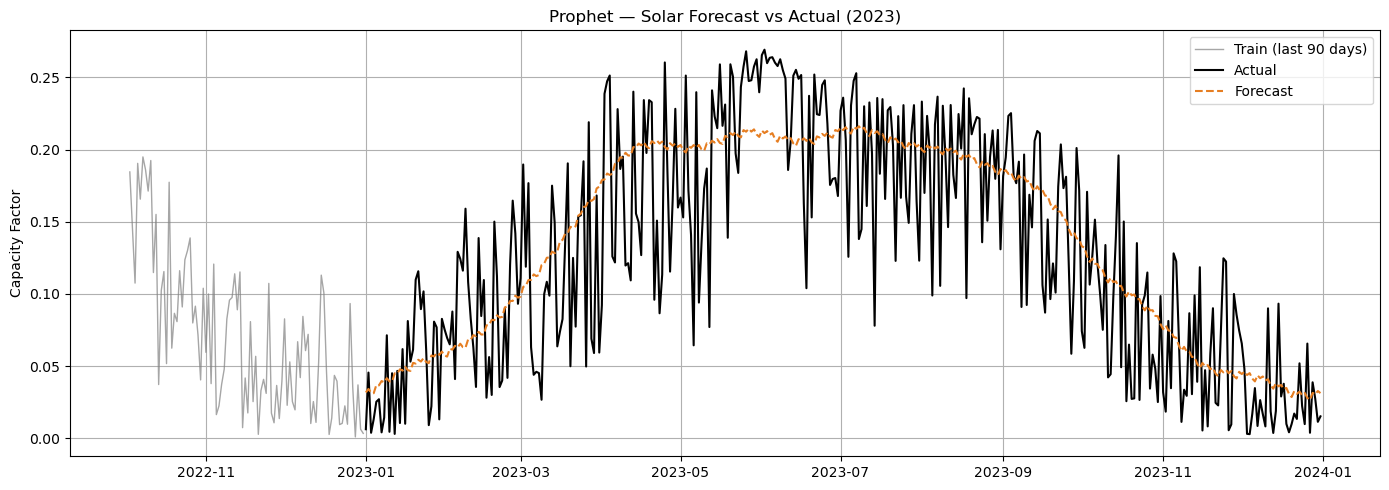

In [17]:
# Forecast
future_solar  = prophet_solar.make_future_dataframe(periods=len(test), freq='D')
forecast_solar = prophet_solar.predict(future_solar)

# Extract only the test period predictions
prophet_solar_pred = forecast_solar.tail(len(test))['yhat'].values
prophet_solar_pred = np.clip(prophet_solar_pred, 0, 1)

res = evaluate(test['solar_cf'], prophet_solar_pred, 'Prophet', 'Solar')
results.append(res)

fig = plot_forecast(
    train['solar_cf'], test['solar_cf'],
    prophet_solar_pred,
    'Prophet — Solar Forecast vs Actual (2023)',
    '#e67e22'
)
fig.savefig('data/prophet_solar_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

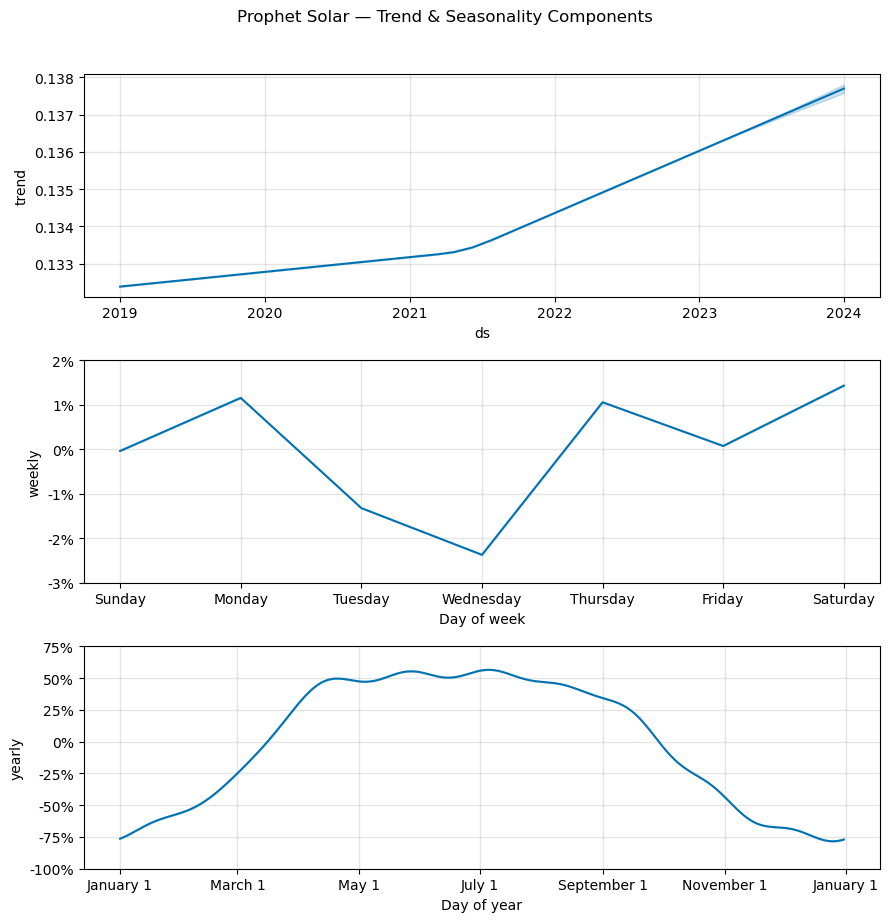

In [18]:
# Prophet component breakdown — great for understanding what drives the forecast
fig_components = prophet_solar.plot_components(forecast_solar)
fig_components.suptitle('Prophet Solar — Trend & Seasonality Components', y=1.02)
plt.tight_layout()
fig_components.savefig('data/prophet_solar_components.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Prophet — Wind

In [20]:
wind_train_prophet = train[['wind_cf']].reset_index().rename(
    columns={'time': 'ds', 'wind_cf': 'y'}
)

print('Fitting Prophet for wind...')
prophet_wind = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # wind doesn't follow a weekly pattern
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.1
)
prophet_wind.fit(wind_train_prophet)
print('Done!')

15:28:39 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet for wind...


15:28:39 - cmdstanpy - INFO - Chain [1] done processing


Done!


[Prophet | Wind]  RMSE: 0.2031   MAE: 0.1589


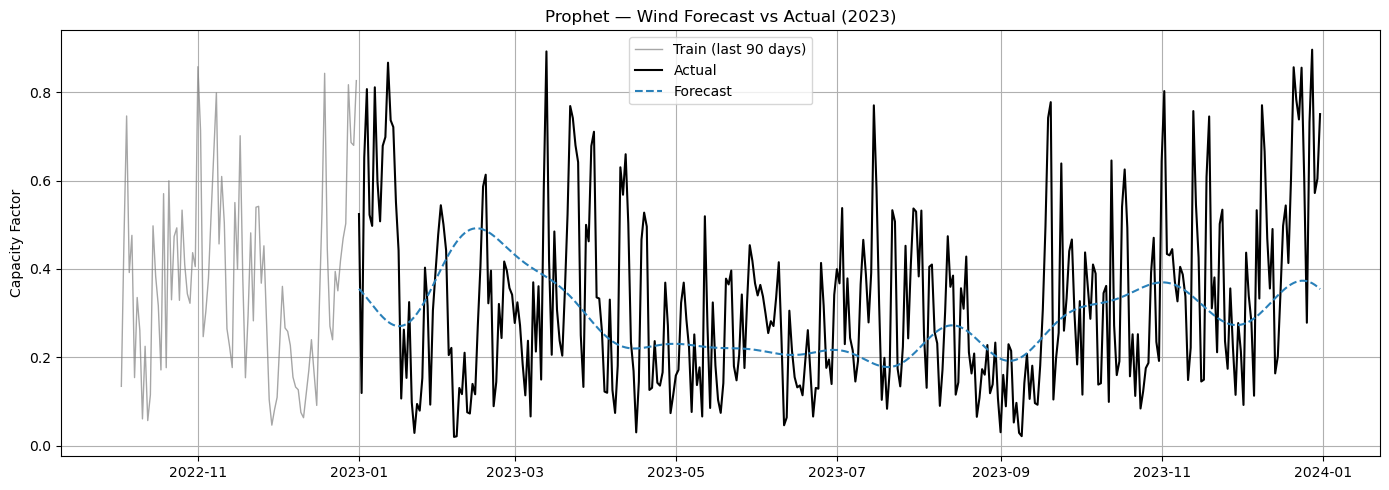

In [21]:
future_wind   = prophet_wind.make_future_dataframe(periods=len(test), freq='D')
forecast_wind = prophet_wind.predict(future_wind)

prophet_wind_pred = forecast_wind.tail(len(test))['yhat'].values
prophet_wind_pred = np.clip(prophet_wind_pred, 0, 1)

res = evaluate(test['wind_cf'], prophet_wind_pred, 'Prophet', 'Wind')
results.append(res)

fig = plot_forecast(
    train['wind_cf'], test['wind_cf'],
    prophet_wind_pred,
    'Prophet — Wind Forecast vs Actual (2023)',
    '#2980b9'
)
fig.savefig('data/prophet_wind_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison

Which model performed better for each energy source?


====== MODEL COMPARISON ======
  model target     rmse      mae
 SARIMA  Solar 0.092873 0.077647
 SARIMA   Wind 0.196543 0.159809
Prophet  Solar 0.047118 0.039056
Prophet   Wind 0.203108 0.158938


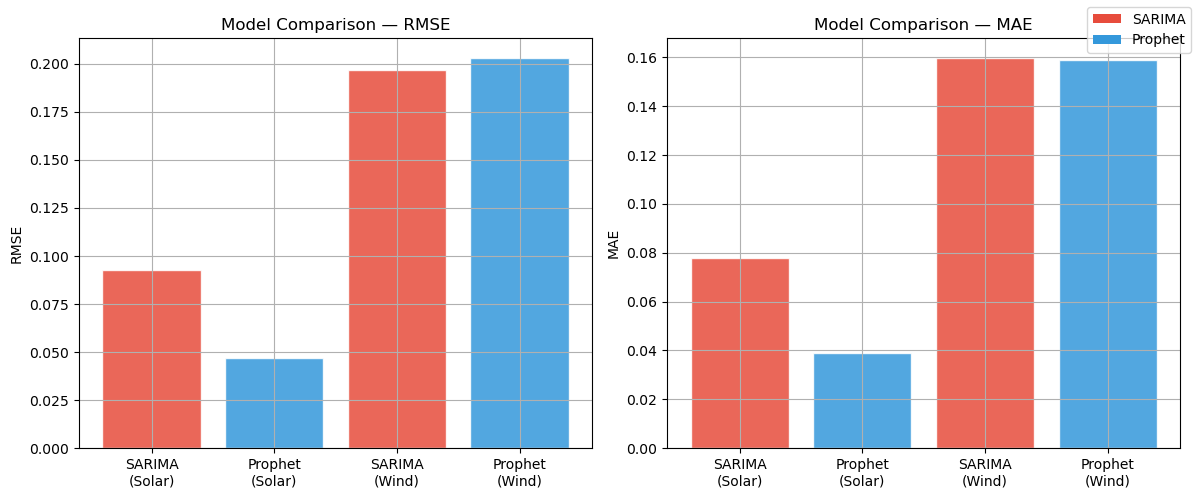

In [23]:
results_df = pd.DataFrame(results)
print('\n====== MODEL COMPARISON ======')
print(results_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
metrics = ['rmse', 'mae']
colors  = {'SARIMA': '#e74c3c', 'Prophet': '#3498db'}

for i, metric in enumerate(metrics):
    for target in ['Solar', 'Wind']:
        subset = results_df[results_df['target'] == target]
        x = np.arange(len(subset))
        bars = axes[i].bar(
            [f"{row['model']}\n({target})" for _, row in subset.iterrows()],
            subset[metric].values,
            color=[colors[m] for m in subset['model']],
            alpha=0.85, edgecolor='white'
        )
    axes[i].set_title(f'Model Comparison — {metric.upper()}')
    axes[i].set_ylabel(metric.upper())

# Add a legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m) for m, c in colors.items()]
fig.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save All Forecasts to CSV

Save everything the dashboard needs in one file.

In [25]:
forecasts = pd.DataFrame({
    'date'               : test.index,
    'solar_actual'       : test['solar_cf'].values,
    'wind_actual'        : test['wind_cf'].values,
    'solar_sarima'       : sarima_solar_pred,
    'wind_sarima'        : sarima_wind_pred,
    'solar_prophet'      : prophet_solar_pred,
    'wind_prophet'       : prophet_wind_pred,
}).set_index('date')

forecasts.to_csv('data/forecasts.csv')
results_df.to_csv('data/model_metrics.csv', index=False)

print('Saved: data/forecasts.csv')
print('Saved: data/model_metrics.csv')
forecasts.head()

Saved: data/forecasts.csv
Saved: data/model_metrics.csv


,solar_actual,wind_actual,solar_sarima,wind_sarima,solar_prophet,wind_prophet
date,,,,,,
2023-01-01,0.006292,0.524292,0.025790,0.638326,0.031777,0.354997
2023-01-02,0.045542,0.119250,0.027593,0.500339,0.034196,0.348440
2023-01-03,0.003833,0.652292,0.026366,0.460153,0.031707,0.341443
2023-01-04,0.013333,0.807208,0.026781,0.437876,0.031240,0.334126
2023-01-05,0.025333,0.522667,0.030802,0.421592,0.036941,0.326618


---
## Phase 3 Complete!

You now have two trained models for both solar and wind, with full metrics and forecasts saved.

**What to note for your write-up / interview:**
- Compare your RMSE values — which model won and why might that be?
- Prophet's component plot shows trend + seasonality decomposed cleanly
- SARIMA is more interpretable statistically; Prophet is more flexible
- Wind is typically harder to forecast than solar (more random)

**Next up: Phase 4 — Streamlit Dashboard**